In [ ]:
# vizualizarea datelor

[Romania] Loading data from: RO_National_Survey_2012\consumption_user.csv...
[Romania] Saving cleaned data to 'Romania_foodex_clean.csv'...


C:\Users\anama\AppData\Local\Temp\ipykernel_4920\1249773472.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ro.values, y=top_ro.index, palette='Blues_d')


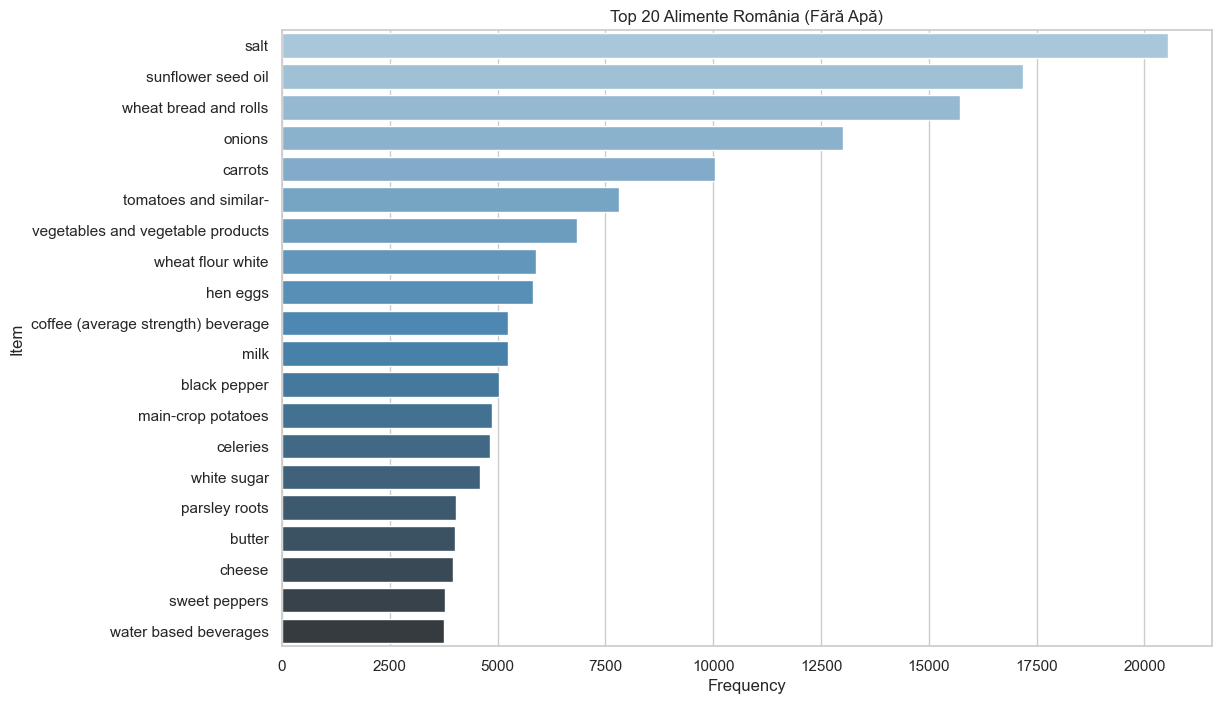

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

def process_romania_foodex(filepath):
    country = "Romania"
    print(f"[{country}] Loading data from: {filepath}...")
    
    try:
        df = pd.read_csv(filepath, usecols=['SUBJECT', 'SURVEY_DAY', 'FOODEX2_INGR_DESCR'], dtype=str)
    except ValueError:
        print(f"Eroare: Nu găsesc coloana 'FOODEX2_INGR_DESCR' în fișierul {filepath}")
        return None

    # 2. Curățare
    df['FOODEX2_INGR_DESCR'] = df['FOODEX2_INGR_DESCR'].fillna('Unknown')
    
    # Process main item
    df['Item'] = df['FOODEX2_INGR_DESCR'].str.split(',').str[0]
    df['Item'] = df['Item'].str.split('#').str[0]
    df['Item'] = df['Item'].str.strip().str.lower()
    
    # --- MODIFICARE AICI: Excludem Apa ---
    # Add 'water', 'drinking water', 'mineral water', etc. to the ignore list
    ignore_list = [
        'unknown', 'other', 'product', 'food', 
        'water', 'drinking water', 'tap water', 'bottled water', 'mineral water'
    ]
    df = df[~df['Item'].isin(ignore_list)]
    
    # 3. ID Tranzacție
    df['Transaction_ID'] = df['SUBJECT'] + "_" + df['SURVEY_DAY']
    
    # 4. Salvare
    out_file = f"{country}_foodex_clean.csv"
    print(f"[{country}] Saving cleaned data to '{out_file}'...")
    df.to_csv(out_file, index=False)
    
    return df

# --- RULARE ROMÂNIA ---
file_ro = r'RO_National_Survey_2012\consumption_user.csv'

try:
    df_ro = process_romania_foodex(file_ro)
    
    if df_ro is not None:
        plt.figure(figsize=(12, 8))
        top_ro = df_ro['Item'].value_counts().head(20)
        sns.barplot(x=top_ro.values, y=top_ro.index, palette='Blues_d')
        plt.title('Top 20 Alimente România (Fără Apă)')
        plt.xlabel('Frequency')
        plt.show()

except FileNotFoundError:
    print(f"Eroare fișier RO: {file_ro}")

[Nigeria] Loading data from: NGA_National_Survey_2017_2018\consumption_user.csv...
[Nigeria] Saving cleaned data to 'Nigeria_foodex_clean.csv'...


C:\Users\anama\AppData\Local\Temp\ipykernel_4920\1005639857.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ng.values, y=top_ng.index, palette='Greens_d')


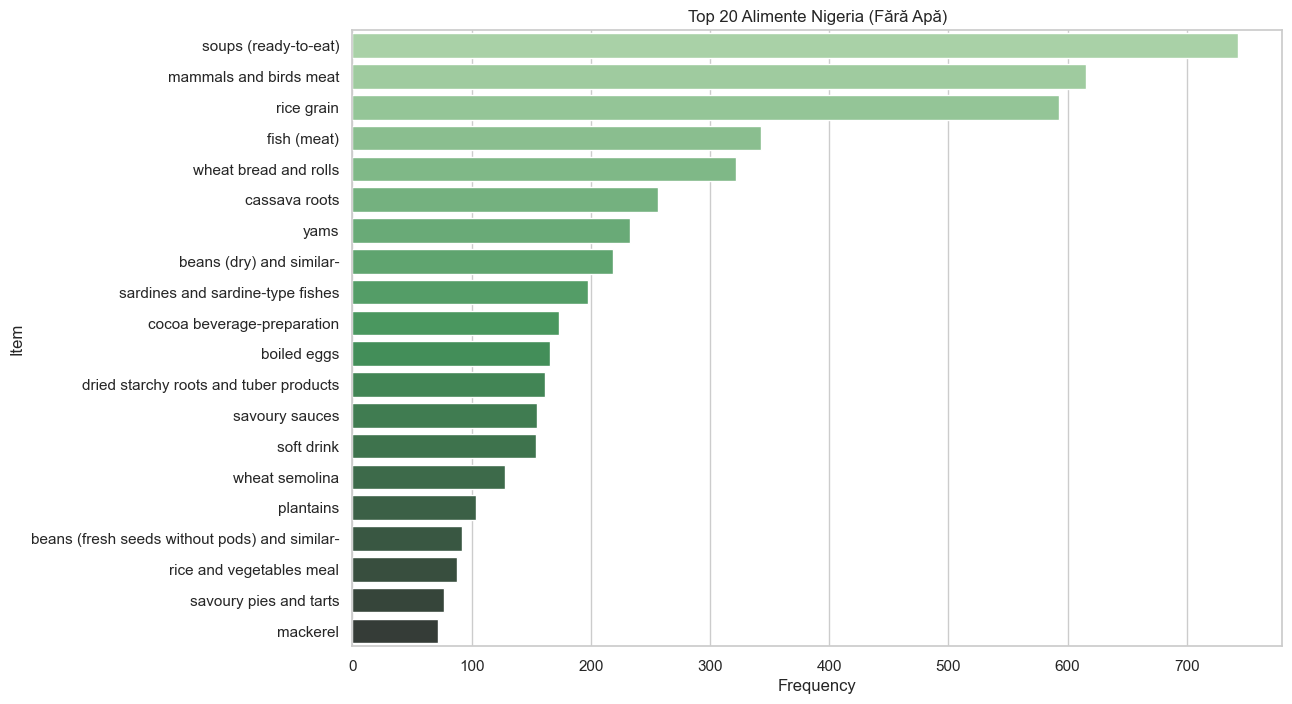

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

def process_nigeria_foodex(filepath):
    country = "Nigeria"
    print(f"[{country}] Loading data from: {filepath}...")
    
    try:
        df = pd.read_csv(filepath, usecols=['SUBJECT', 'SURVEY_DAY', 'FOODEX2_INGR_DESCR'], dtype=str)
    except ValueError:
        print(f"Eroare: Nu găsesc coloana 'FOODEX2_INGR_DESCR' în fișierul {filepath}")
        return None
        
    # 2. Curățare
    df['FOODEX2_INGR_DESCR'] = df['FOODEX2_INGR_DESCR'].fillna('Unknown')
    
    # Process main item
    df['Item'] = df['FOODEX2_INGR_DESCR'].str.split(',').str[0]
    df['Item'] = df['Item'].str.split('#').str[0]
    df['Item'] = df['Item'].str.strip().str.lower()
    
    # --- MODIFICARE AICI: Excludem Apa ---
    ignore_list = [
        'unknown', 'other', 'product', 'food', 
        'water', 'drinking water', 'tap water', 'bottled water', 'mineral water'
    ]
    df = df[~df['Item'].isin(ignore_list)]
    
    # 3. ID Tranzacție
    df['Transaction_ID'] = df['SUBJECT'] + "_" + df['SURVEY_DAY']
    
    # 4. Salvare
    out_file = f"{country}_foodex_clean.csv"
    print(f"[{country}] Saving cleaned data to '{out_file}'...")
    df.to_csv(out_file, index=False)
    
    return df

# --- RULARE NIGERIA ---
file_ng = r'NGA_National_Survey_2017_2018\consumption_user.csv'

try:
    df_ng = process_nigeria_foodex(file_ng)
    
    if df_ng is not None:
        plt.figure(figsize=(12, 8))
        top_ng = df_ng['Item'].value_counts().head(20)
        sns.barplot(x=top_ng.values, y=top_ng.index, palette='Greens_d')
        plt.title('Top 20 Alimente Nigeria (Fără Apă)')
        plt.xlabel('Frequency')
        plt.show()

except FileNotFoundError:
    print(f"Eroare fișier NG: {file_ng}")